### A Hebbian learning network with 1 layer

Part 1: Simulating the input data $\mathbf{x}$ and the target output $\mathbf{y}$

Part 2: Implementing Oja's Learning Rule

Part 3: Implementing Sanger's Rule

Part 4: Training the Network, and visualizing the Loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from hebbian.models import HebbianModel, OjaNetwork, SangerNetwork

### Model Structure

In [2]:
# HebbianModel

### Oja's multi-neuron model
$$
\mathbf{x \in \mathbb{R}^n}
$$

$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$

$$
\mathbf{yx^\top \in \mathbb{R}^{m \times n}}
$$
$$
\mathbf{W \in \mathbb{R}^{m \times n}}
$$
$$
\mathbf{yy^\top = \mathbb{R}^{k \times k}}
$$

$$
\mathbf{\Delta W = \eta (yx^\top - y y^\top W)}
$$


In [3]:
# OjaNetwork

### Sanger's multi-neuron model

$$
\mathbf{yy^\top = \begin{bmatrix}
    y_1 y_1 & y_1 y_2 & \cdots & y_1 y_k \\
    y_2 y_1 & y_2 y_2 & \cdots & y_2 y_k \\
    \vdots & \vdots & \ddots & \vdots \\
    y_k y_1 & y_k y_2 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{B = \begin{bmatrix}
    y_1 y_1 & 0 & \cdots & 0 \\
    y_2 y_1 & y_2 y_2 & \cdots & 0 \\
    \vdots & \vdots & \ddots & \vdots \\
    y_k y_1 & y_k y_2 & \cdots & y_k y_k
\end{bmatrix}}
$$

$$
\mathbf{\Delta W = \eta (y x^\top - B W)}
$$



In [4]:
# SangerNetwork

### Training and testing: alignment to PCs

In [21]:
from hebbian.utils import pca_topk, cosine_alignment, training_testing, gauss_distrib, plot_samples_and_top2_pcs, plot_samples_and_top3_pcs_3d, generate_covariance_matrix

In [6]:
def testing_alignment(model, X, epochs, pcs, shuffle=False, method="epochs"):
    """
    Record cosine alignment(s) while training, either:
      - per epoch  (method='epochs'): one snapshot after each epoch
      - per trials (method='trials'): snapshot after each step
    """
    X = np.asarray(X, float)
    N = len(X)
    align_hist = []

    def align_from_W(weights):
        # single-output
        if weights.ndim == 1 or (weights.ndim == 2 and weights.shape[0] == 1):
            w = weights if weights.ndim == 1 else weights[0, :]
            return cosine_alignment(w, pcs[0])
        else:
            m = min(weights.shape[0], len(pcs))
            return [cosine_alignment(weights[i, :], pcs[i]) for i in range(m)]

    for _ in range(int(epochs)):
        if method == "epochs":
            model.train(X, epochs=1, shuffle=shuffle)  # one epoch
            align_hist.append(align_from_W(model.weights))
        elif method == "trials":
            idx = np.arange(N)
            if shuffle:
                model.rng.shuffle(idx)
            for i in idx:
                model.step(X[i])
                align_hist.append(align_from_W(model.weights))
        else:
            raise ValueError("method must be 'epochs' or 'trials'.")
    return align_hist


In [7]:
mu1 = 0.0
std1 = 0.3
mu2 = 0.0
std2 = 0.9
orientation = np.random.random() * np.pi
number_of_neurons = 2
number_of_samples = 2000
learning_rate = 0.1

### Test samples: 2D

{'pcs': array([[ 0.09868951, -0.99511827],
        [-0.99511827, -0.09868951]]),
 'eigvals': array([0.80077074, 0.08865602]),
 'mean': array([-1.05471187e-17, -1.51267887e-17])}

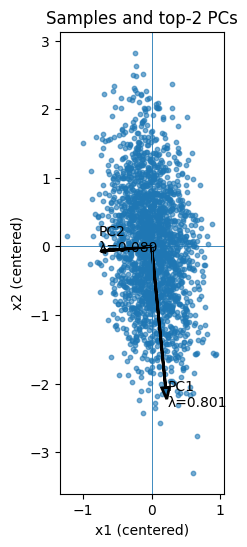

In [8]:
# We precompute the samples
samples_2d = gauss_distrib(orientation, mu1,std1,mu2,std2,number_of_samples)

# get eigenvalues
plot_samples_and_top2_pcs(samples_2d)

### Test samples: 3D

/var/folders/gz/j8z1vy514q51r1gxg3zf8s_h0000gn/T/ipykernel_15387/1885478904.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


{'pcs': array([[ 0.23820334,  0.96990656, -0.05040282],
        [ 0.57443216, -0.18254336, -0.79793835],
        [ 0.78312634, -0.16111858,  0.60062796]]),
 'eigvals': array([1.637424  , 0.21243592, 0.08666837]),
 'mean': array([ 1.12965193e-17, -2.09832152e-17,  4.50750548e-17])}

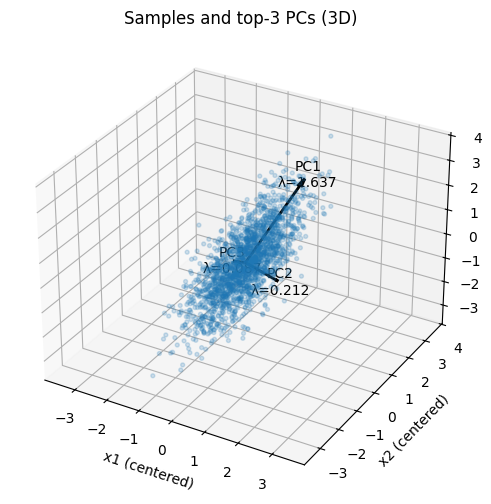

In [9]:
mu = np.array([0.0, 0.0, 0.0])   # means for 3 neurons
cov = np.array([[0.3, 0.2, 0.3],   # covariance matrix (3x3, symmetric, PSD)
                [0.2, 0.5, 0.8],
                [0.3, 0.8, 1.0]])
samples_3d = np.random.multivariate_normal(mu, cov, size=number_of_samples)

# Center the data (zero mean)
samples_3d -= samples_3d.mean(axis=0, keepdims=True)

plot_samples_and_top3_pcs_3d(samples_3d, center=True, scale=2.5, annotate=True)


### Test samples: N-D

### 2D Oja and Sanger multi-neuron networks

In [11]:
model1 = OjaNetwork(output_size=2, learning_rate=learning_rate)
model2 = SangerNetwork(output_size=2, learning_rate=learning_rate)

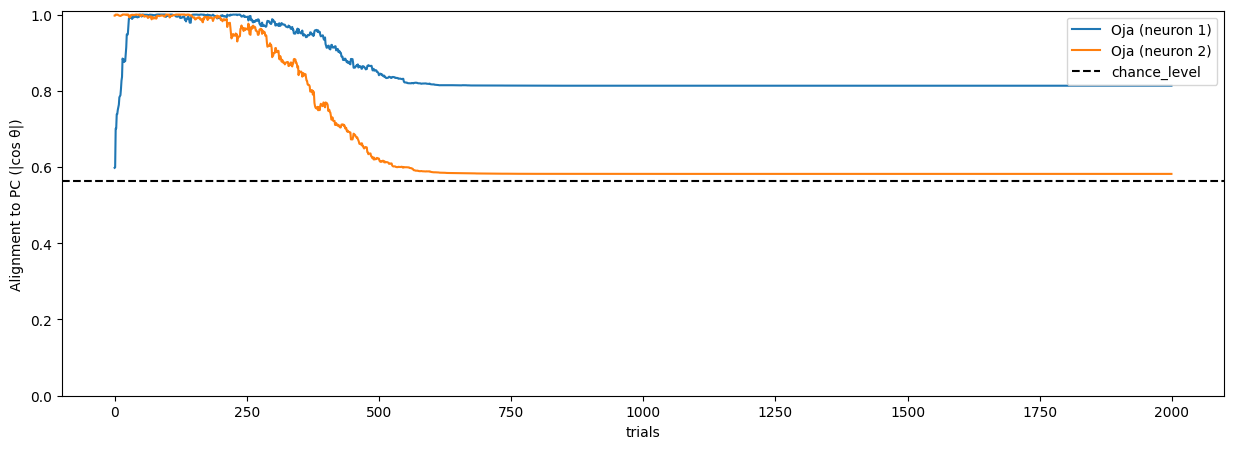

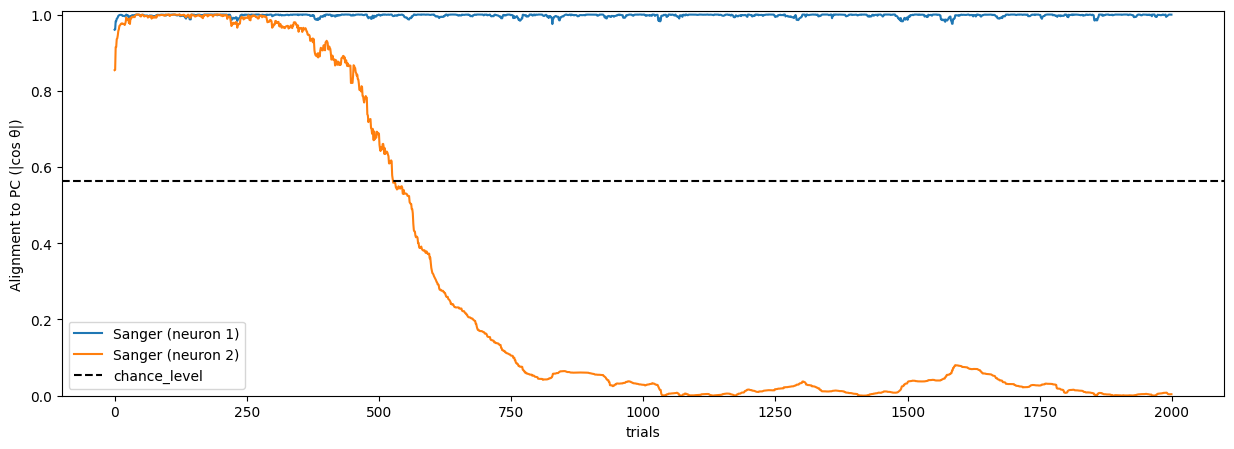

In [12]:
training_testing(samples_2d, models = {"Oja": model1, "Sanger": model2}, output_size=2,
                       pc_method = "first", alignment_method = "weights",
                       show_num = None)

### 3D Oja and Sanger multi-neuron networks

In [13]:
model1 = OjaNetwork(output_size=2, learning_rate=learning_rate)
model2 = SangerNetwork(output_size=2, learning_rate=learning_rate)

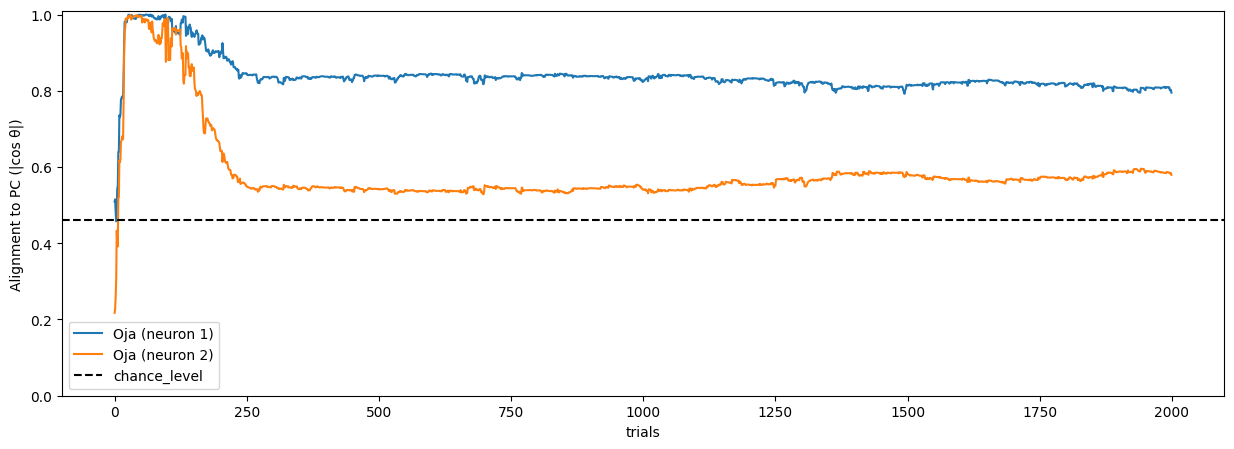

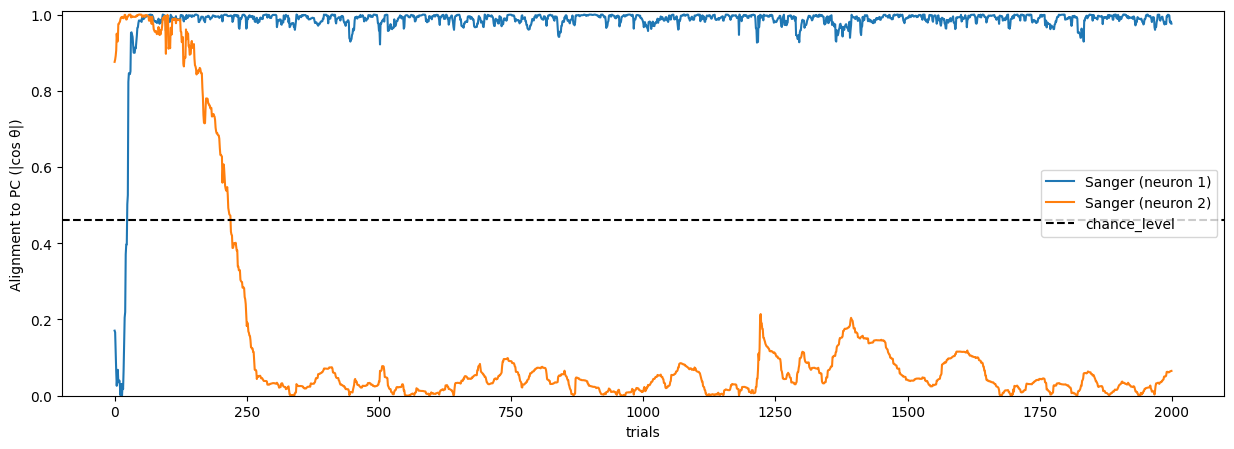

In [14]:
training_testing(samples_3d, models = {"Oja": model1, "Sanger": model2}, output_size=3,
                       pc_method = "first", alignment_method = "weights",
                       show_num = None)

### 3D Oja's and Sanger's multi-neuron model in 2D samples.

In [15]:
model1 = OjaNetwork(output_size=2, learning_rate=learning_rate)
model2 = SangerNetwork(output_size=2, learning_rate=learning_rate)

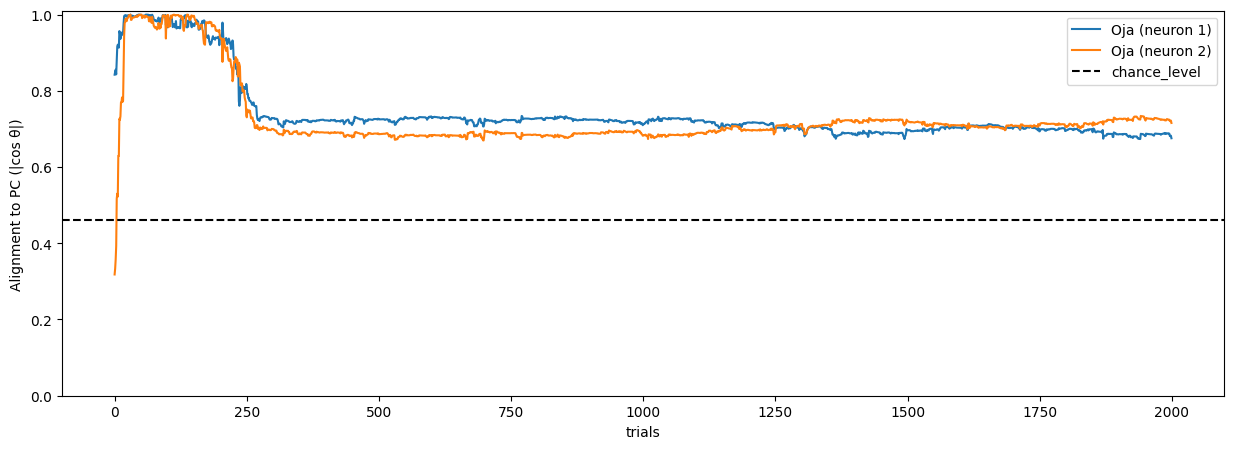

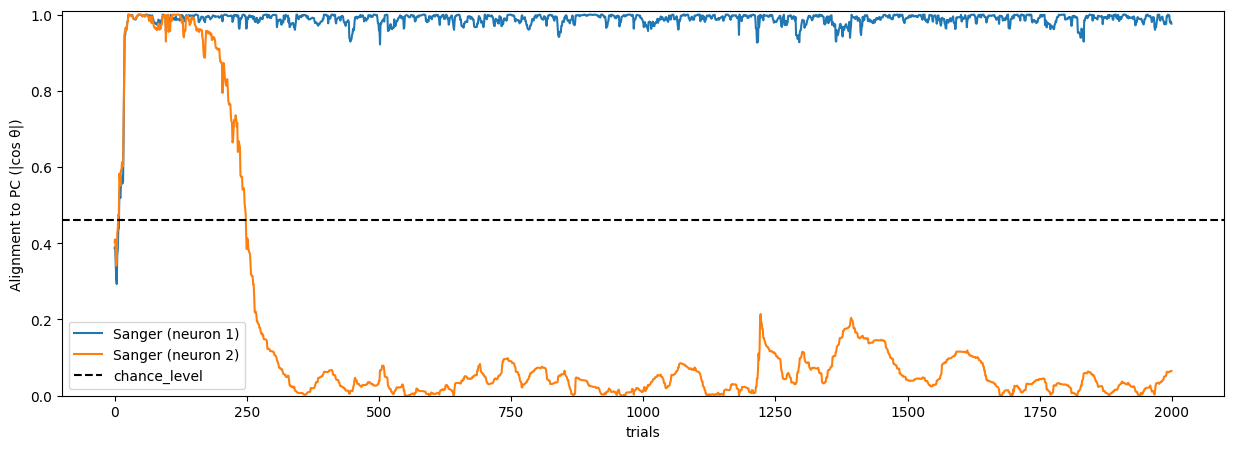

In [16]:
training_testing(samples_3d, models = {"Oja": model1, "Sanger": model2}, output_size=2,
                       pc_method = "first", alignment_method = "weights",
                       show_num = None)

### Oja and Sanger multi-neuron networks for N-D samples
N = 10

In [32]:
# 10-dimensional mean vector
mu = np.zeros(10)

# 10x10 covariance matrix (symmetric, PSD)
cov = generate_covariance_matrix(10, method = 'eigenvalues', eigenvalues = [1, 0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

# sample data
samples_10d = np.random.multivariate_normal(mu, cov, size=number_of_samples)


In [33]:
model1 = OjaNetwork(output_size=5, learning_rate=learning_rate)
model2 = SangerNetwork(output_size=5, learning_rate=learning_rate)

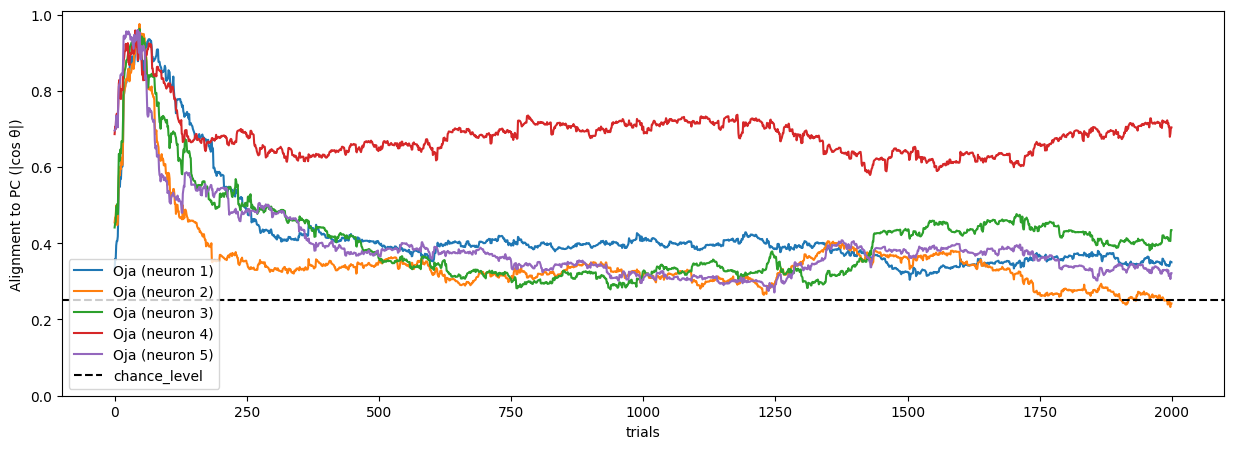

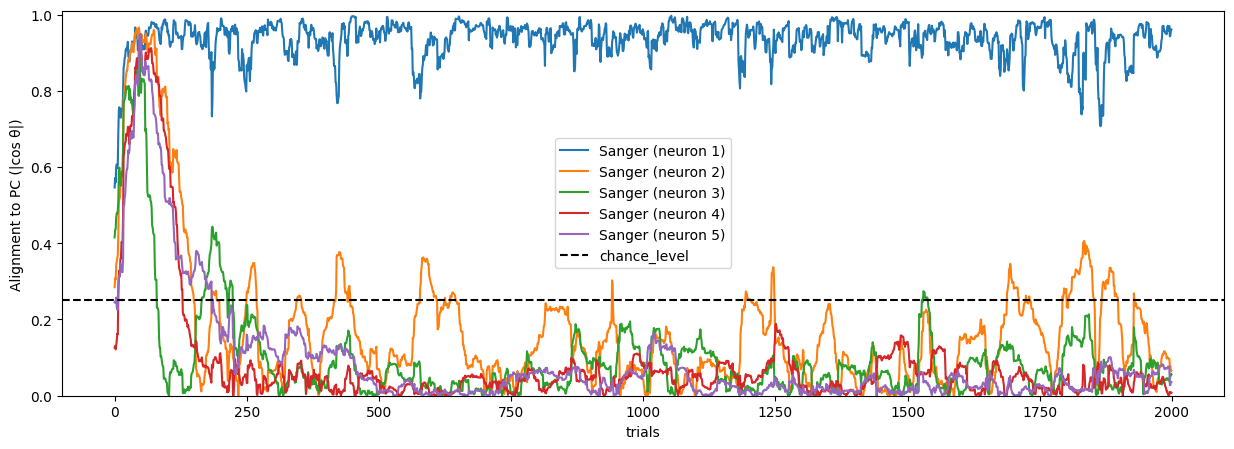

In [34]:
training_testing(samples_10d, models = {"Oja": model1, "Sanger": model2}, output_size=5, 
                pc_method = "first", alignment_method = "weights", show_num = None)

### Bonus: check the variances of output to align with eigenvalues

In [35]:
from hebbian.utils import estimate_output_variances

In [37]:
weights_ojaK = model1.W
weights_sangerK = model2.W

In [38]:
X = samples_10d
# Eigenvalue
print(f"PCs eigenvalues: {pca_topk(X, X.shape[1], center=True)[1]}")
print(f"Sanger: {estimate_output_variances(X, weights_sangerK)}")
print(f"Oja: {estimate_output_variances(X, weights_ojaK)}")

PCs eigenvalues: [1.03732774 0.4888443  0.31229702 0.1858454  0.11079943 0.10488539
 0.10052724 0.09624268 0.09568258 0.09330519]
Sanger: [0.96649972 0.46237652 0.32532947 0.1868521  0.11415298]
Oja: [0.28902356 0.31340981 0.44306974 0.69041983 0.34701994]


### Bonus 2: Subspace check
The results of $\mathbf{w^\top w \approx I_n}$